In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Q3.Fine-Tuning YOLO on a Custom Dataset:
a. Train a YOLOv5 model on a custom dataset using Ultralytics YOLOv5.
b. Evaluate the trained model on test images and calculate mAP (Mean Average 
Precision).**

In [6]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17360, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 17360 (delta 36), reused 18 (delta 18), pack-reused 17308 (from 2)
Receiving objects: 100% (17360/17360), 16.24 MiB | 32.87 MiB/s, done.
Resolving deltas: 100% (11904/11904), done.
/kaggle/working/yolov5


In [7]:
!pip install xmltodict

In [8]:
import os
import xmltodict


In [16]:
def convert_voc_to_yolo(xml_file, img_width, img_height):
    with open(xml_file) as f:
        doc = xmltodict.parse(f.read())

    objects = doc["annotation"]["object"]
    objects = objects if isinstance(objects, list) else [objects]  # Handle single object case

    yolo_annotations = []
    for obj in objects:
        class_name = obj["name"]
        if class_name not in classes:
            continue  # Skip unknown classes

        class_id = classes.index(class_name)  # Convert class name to index
        bbox = obj["bndbox"]
        xmin, ymin, xmax, ymax = map(float, [bbox["xmin"], bbox["ymin"], bbox["xmax"], bbox["ymax"]])

        # Normalize coordinates (convert to YOLO format)
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_annotations.append(f"{class_id} {x_center} {y_center} {width} {height}")

    return yolo_annotations


In [18]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt
!python train.py --img 416 --batch 16 --epochs 5 --data coco128.yaml --weights yolov5s.pt


Cloning into 'yolov5'...
remote: Enumerating objects: 17360, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 17360 (delta 36), reused 18 (delta 18), pack-reused 17308 (from 2)
Receiving objects: 100% (17360/17360), 16.25 MiB | 28.35 MiB/s, done.
Resolving deltas: 100% (11901/11901), done.
/kaggle/working/yolov5/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-04-03 06:48:59.840868: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-03 06:49:00.128125: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-03 06:49:00.213473: E e

In [20]:
!python val.py --weights runs/train/exp/weights/best.pt --data coco128.yaml --img 416


val: data=/kaggle/working/yolov5/yolov5/data/coco128.yaml, weights=['runs/train/exp/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
val: Scanning /kaggle/working/yolov5/datasets/coco128/labels/train2017.cache... 
                 Class     Images  Instances          P          R      mAP50   
                   all        128        929      0.614      0.589      0.646      0.405
Speed: 0.1ms pre-process, 6.2ms inference, 6.1ms NMS per image at shape (32, 3, 416, 416)
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid v

In [26]:
import shutil

image_path = "/kaggle/input/test-image/Calangute beach goa.png"  # Change this if your file has a different name
destination_path = "/kaggle/working/yolov5_test.jpg"

# Copy instead of move
shutil.copy(image_path, destination_path)

print("✅ Image copied successfully!")


✅ Image copied successfully!


In [31]:
!python detect.py --weights runs/train/exp/weights/best.pt --source /kaggle/working/yolov5_test.jpg --img 416 --conf 0.4 --save-txt --project /kaggle/working/runs/detect/ --name my_exp


detect: weights=['runs/train/exp/weights/best.pt'], source=/kaggle/working/yolov5_test.jpg, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/runs/detect/, name=my_exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/1 /kaggle/working/yolov5_test.jpg: 256x416 3 persons, 2 umbrellas, 2 chairs, 27.1ms
Speed: 0.3ms pre-process, 27.1ms inference, 214.6ms NMS per image at shape (1, 3, 416, 416)
Results saved to /kaggle/working/runs/detect/my_exp
1 labels saved to /kaggle/working/runs/detect/my

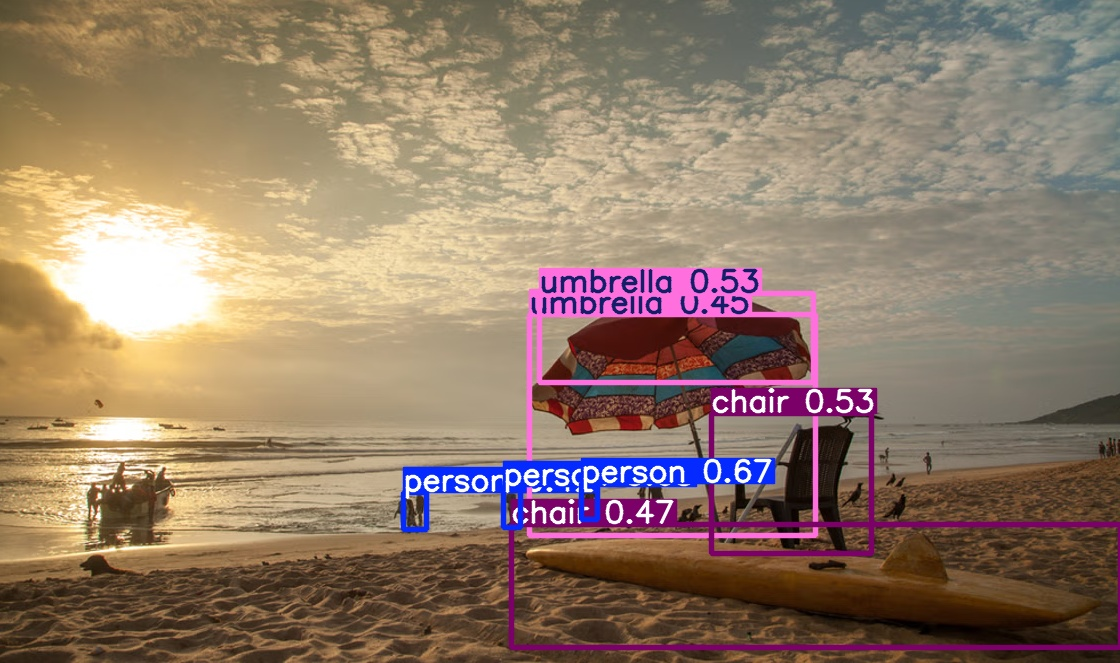

In [32]:
from IPython.display import Image
import os

# Define the path where YOLOv5 saved the output image
output_folder = "/kaggle/working/runs/detect/my_exp/"
detected_images = [f for f in os.listdir(output_folder) if f.endswith(('.jpg', '.png'))]

if detected_images:
    detected_image_path = os.path.join(output_folder, detected_images[0])  # Take the first detected image
    display(Image(filename=detected_image_path))
else:
    print(f"❌ No detected image found in: {output_folder}")


**Q4 YOLO on Video Streams:
a. Modify the YOLO script to process a live webcam feed or a recorded video.
b. Display the FPS (Frames Per Second) on the video to analyze YOLO’s realtime performance.**

In [1]:
!pip install ultralytics opencv-python numpy torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 23.3 MB/s eta 0:00:0000:01


In [2]:
from ultralytics import YOLO

# Download YOLOv8 model if not already present
!yolo task=detect mode=predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100%|███████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 123MB/s]
Ultralytics 8.3.100 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100%|██████████████████████████████████████| 49.2k/49.2k [00:00<00:00, 6.91MB/s]
image 1/1 /kaggle/working/zidane.jpg: 384x640 2 persons, 1 tie, 56.3ms
Speed: 12.4ms preprocess, 56.3ms inference, 300.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [3]:
import cv2
import time
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Load the uploaded video
video_path = "/kaggle/input/paddle-surfing-and-scuba-video/paddle_surfing_scubavideo.mp4"  # Change this to your uploaded file name
cap = cv2.VideoCapture(video_path)

# Get video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))
output_path = "output.mp4"

# Define codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

# Process each frame
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    start_time = time.time()

    # Run YOLO on the frame
    results = model(frame)

    # Draw bounding boxes
    annotated_frame = results[0].plot()

    # Calculate FPS
    end_time = time.time()
    fps_display = int(1 / (end_time - start_time))

    # Display FPS on frame
    cv2.putText(annotated_frame, f'FPS: {fps_display}', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 
                1, (0, 255, 0), 2, cv2.LINE_AA)

    # Save the processed frame
    out.write(annotated_frame)

cap.release()
out.release()
cv2.destroyAllWindows()

print("✅ Processed video saved as:", output_path)



0: 384x640 2 persons, 2 surfboards, 50.5ms
Speed: 4.2ms preprocess, 50.5ms inference, 169.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 3 surfboards, 7.4ms
Speed: 2.6ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 2 surfboards, 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 2 surfboards, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 2 surfboards, 6.4ms
Speed: 1.4ms preprocess, 6.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 2 surfboards, 6.4ms
Speed: 1.5ms preprocess, 6.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 2 surfboards, 7.6ms
Speed: 1.6ms preprocess, 7.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 

In [4]:
import IPython.display as display
import cv2

# Load the processed video
video_path = "/kaggle/working/output.mp4"

# Play the video inside the notebook
display.display(display.Video(video_path, embed=True))


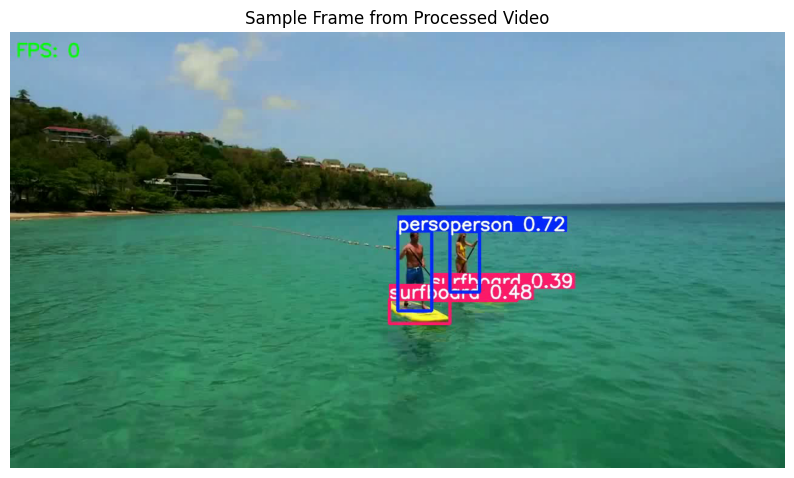

In [5]:
import cv2
import matplotlib.pyplot as plt

# Load the processed video
cap = cv2.VideoCapture("/kaggle/working/output.mp4")

# Read the first frame
success, frame = cap.read()

if success:
    # Convert to RGB for displaying in Matplotlib
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Display the frame
    plt.figure(figsize=(10,6))
    plt.imshow(frame)
    plt.axis("off")
    plt.title("Sample Frame from Processed Video")
    plt.show()

cap.release()
